### Data Ingestion & Index Validation

In [3]:
import sys
print(sys.executable)


d:\GRIND\Data Analyst\Hiring-Projects\apparel-sales-forecasting\py_env\Scripts\python.exe


In [4]:
from pathlib import Path
import sys
import pandas as pd
import os

current_dir = Path(os.getcwd())

PROJECT_ROOT = str(current_dir.parent) 

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.eda import load_and_validate_dataset

CSV_PATH = Path("../reports/00-monthly_macro_apparel.csv")
df = load_and_validate_dataset(CSV_PATH)

sales_nsa = df.loc["1992-01-01":"2026-07-01", "apparel_sales_nsa"]
sales_sa = df.loc["1992-01-01":"2026-07-01", "apparel_sales_sa"]

print(
    f"Successfully validated DatetimeIndex. Total sales records: {len(sales_nsa)} months."
)

Successfully validated DatetimeIndex. Total sales records: 415 months.


In [5]:
import src.eda
print(dir(src.eda))


['Path', 'STL', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'adfuller', 'calculate_dec_jan_ratio', 'compute_exogenous_ccf', 'kpss', 'load_and_validate_dataset', 'np', 'pd', 'plot_acf', 'plot_pacf', 'plt', 'run_stationarity_matrix', 'sns']


### Primary Time Series Plot & Annotations

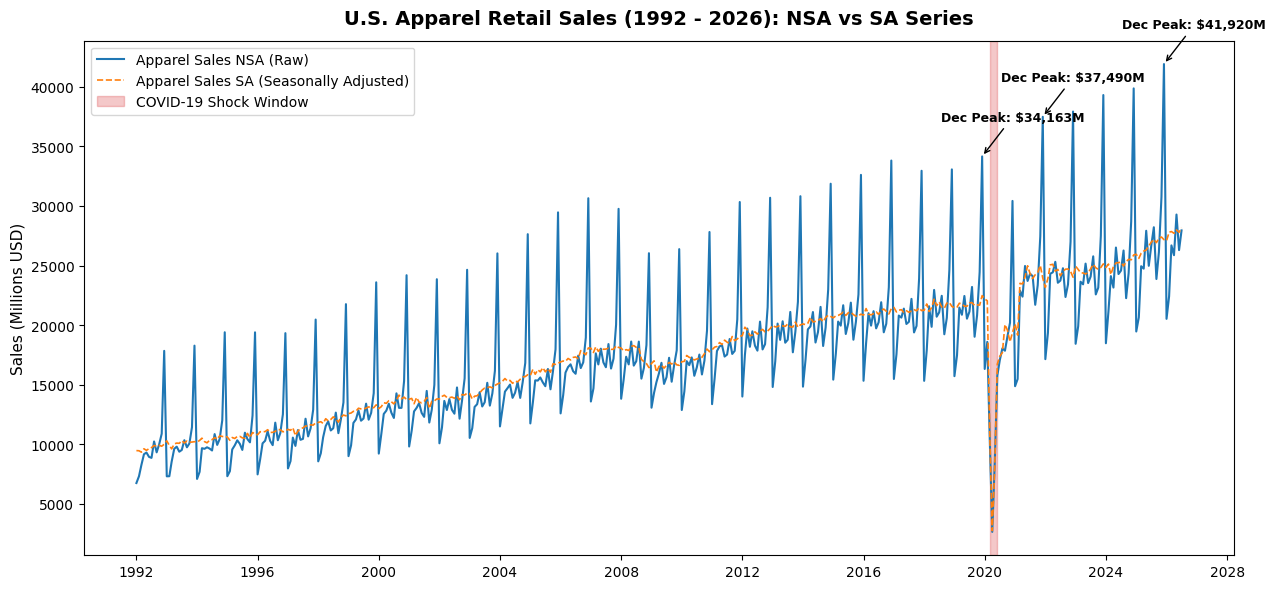

In [8]:
import matplotlib.pyplot as plt
from pathlib import Path

FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    sales_nsa.index,
    sales_nsa.values,
    label="Apparel Sales NSA (Raw)",
    color="#1f77b4",
    linewidth=1.5,
)
ax.plot(
    sales_sa.index,
    sales_sa.values,
    label="Apparel Sales SA (Seasonally Adjusted)",
    color="#ff7f0e",
    linestyle="--",
    linewidth=1.2,
)

# Shade COVID-19 Shock Window
ax.axvspan(
    pd.Timestamp("2020-03-01"),
    pd.Timestamp("2020-06-01"),
    color="#d62728",
    alpha=0.25,
    label="COVID-19 Shock Window",
)

# Annotate key December peaks
dec_peaks = [
    (pd.Timestamp("2019-12-01"), sales_nsa.loc["2019-12-01"]),
    (pd.Timestamp("2021-12-01"), sales_nsa.loc["2021-12-01"]),
    (pd.Timestamp("2025-12-01"), sales_nsa.loc["2025-12-01"]),
]

for dt, val in dec_peaks:
    ax.annotate(
        f"Dec Peak: ${val:,.0f}M",
        xy=(dt, val),
        xytext=(dt - pd.Timedelta(days=500), val + 3000),
        arrowprops=dict(facecolor="black", arrowstyle="->", lw=1),
        fontsize=9,
        fontweight="bold",
    )

ax.set_title(
    "U.S. Apparel Retail Sales (1992 - 2026): NSA vs SA Series",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
ax.set_ylabel("Sales (Millions USD)", fontsize=11)
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "fig1_nsa_vs_sa_overview.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Seasonality & December/January Peak Ratio Analysis

C:\Users\aboal\AppData\Local\Temp\ipykernel_17140\2574156061.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


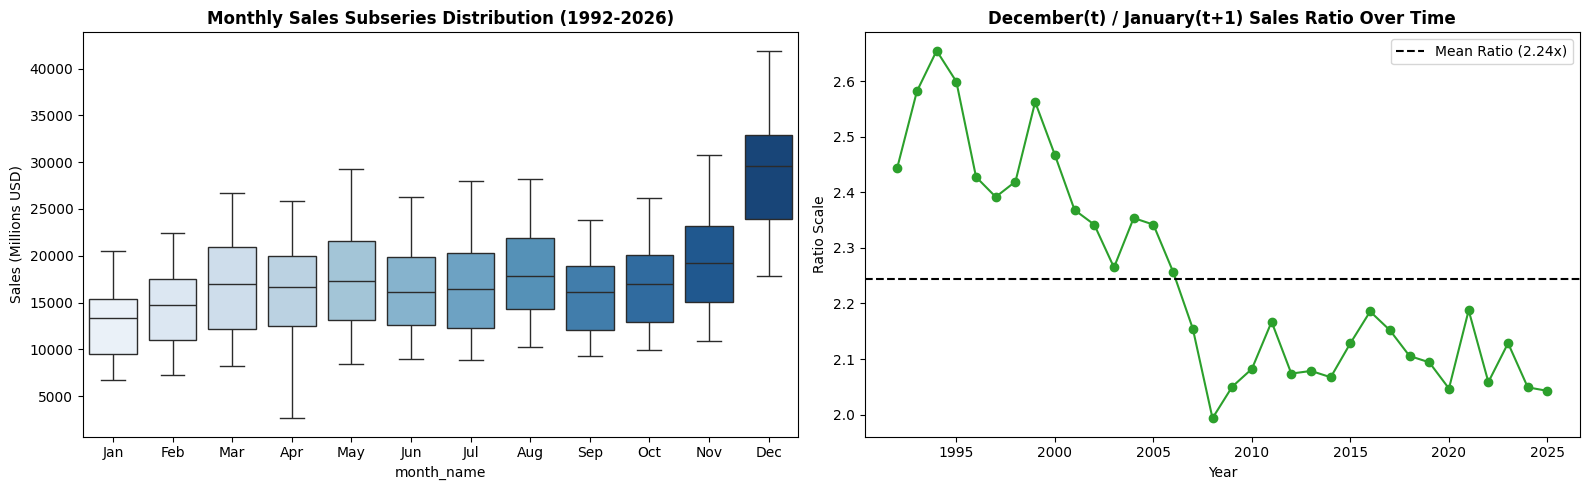

In [9]:
import seaborn as sns
from src.eda import calculate_dec_jan_ratio

# Subseries Boxplot
df_sub = sales_nsa.to_frame().copy()
df_sub["month_name"] = df_sub.index.strftime("%b")
month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(
    data=df_sub,
    x="month_name",
    y="apparel_sales_nsa",
    order=month_order,
    ax=ax1,
    palette="Blues",
)
ax1.set_title(
    "Monthly Sales Subseries Distribution (1992-2026)",
    fontsize=12,
    fontweight="bold",
)
ax1.set_ylabel("Sales (Millions USD)")

# Dec/Jan Ratio Plot
ratio_df = calculate_dec_jan_ratio(df)
ax2.plot(
    ratio_df.index,
    ratio_df["dec_jan_ratio"],
    marker="o",
    color="#2ca02c",
    linewidth=1.5,
)
ax2.axhline(
    ratio_df["dec_jan_ratio"].mean(),
    color="black",
    linestyle="--",
    label=f'Mean Ratio ({ratio_df["dec_jan_ratio"].mean():.2f}x)',
)
ax2.set_title(
    "December(t) / January(t+1) Sales Ratio Over Time",
    fontsize=12,
    fontweight="bold",
)
ax2.set_ylabel("Ratio Scale")
ax2.set_xlabel("Year")
ax2.legend()

plt.tight_layout()
plt.savefig(
    "../reports/figures/fig2_seasonality_and_dec_jan_ratio.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Growth Regimes & Macro Economic Events

Using our YoY growth and rolling average calculations (reports/01_yoy_growth.csv and reports/02_rolling_12m_avg.csv), we mark four macro economic regimes:

- 2008–2009 Great Recession: Prolonged structural contraction.

- 2020 COVID Shock: Unprecedented acute drop.

- 2021 Stimulus Rebound: Explosive recovery driven by fiscal policy.

- 2022 Inflationary Period: Revenue expansion driven by rising CPI price levels.

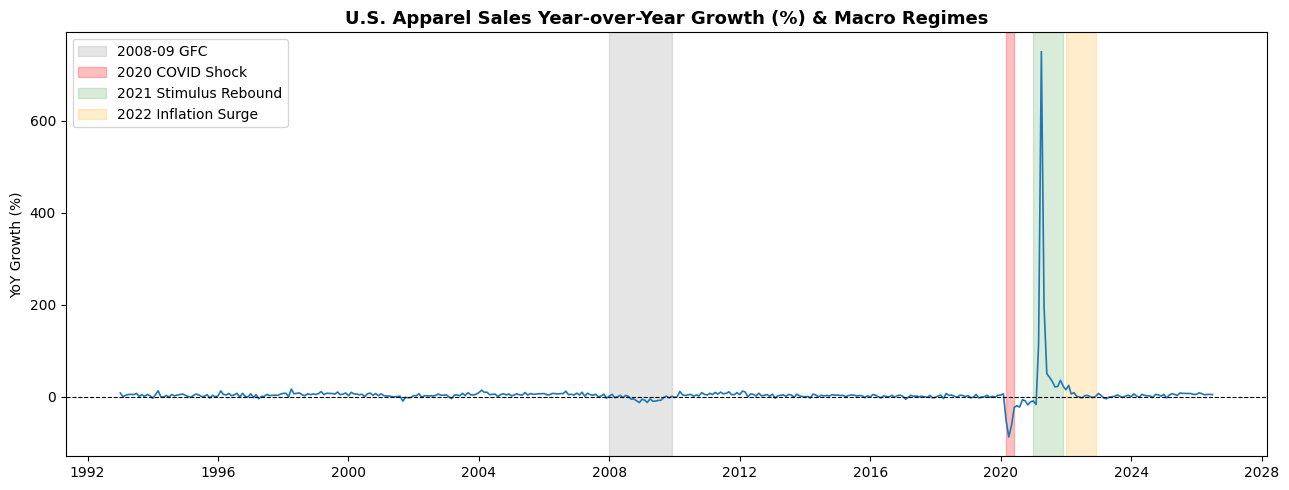

In [11]:
df_yoy = pd.read_csv("../reports/01-yoy_sales_growth.csv", parse_dates=["observation_date"]).set_index("observation_date")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_yoy.index, df_yoy["yoy_growth_percentage"], color="#1f77b4", linewidth=1.2)
ax.axhline(0, color="black", linestyle="--", linewidth=0.8)

# Highlight Regimes
ax.axvspan(pd.Timestamp("2008-01-01"), pd.Timestamp("2009-12-01"), color="grey", alpha=0.2, label="2008-09 GFC")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-06-01"), color="red", alpha=0.25, label="2020 COVID Shock")
ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2021-12-01"), color="green", alpha=0.15, label="2021 Stimulus Rebound")
ax.axvspan(pd.Timestamp("2022-01-01"), pd.Timestamp("2022-12-01"), color="orange", alpha=0.2, label="2022 Inflation Surge")

ax.set_title("U.S. Apparel Sales Year-over-Year Growth (%) & Macro Regimes", fontsize=13, fontweight="bold")
ax.set_ylabel("YoY Growth (%)")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("../reports/figures/fig3_growth_regimes_yoy.png", dpi=300, bbox_inches="tight")
plt.show()

### Variance & Log Transformation JustificationIn

 time series with multiplicative seasonality ($y_t = T_t \times S_t \times I_t$), the seasonal amplitude expands proportionally as the trend level increases. Applying a natural logarithm transforms multiplicative relationships into additive form ($\ln(y_t) = T_t' + S_t' + I_t'$), stabilizing variance across the series.

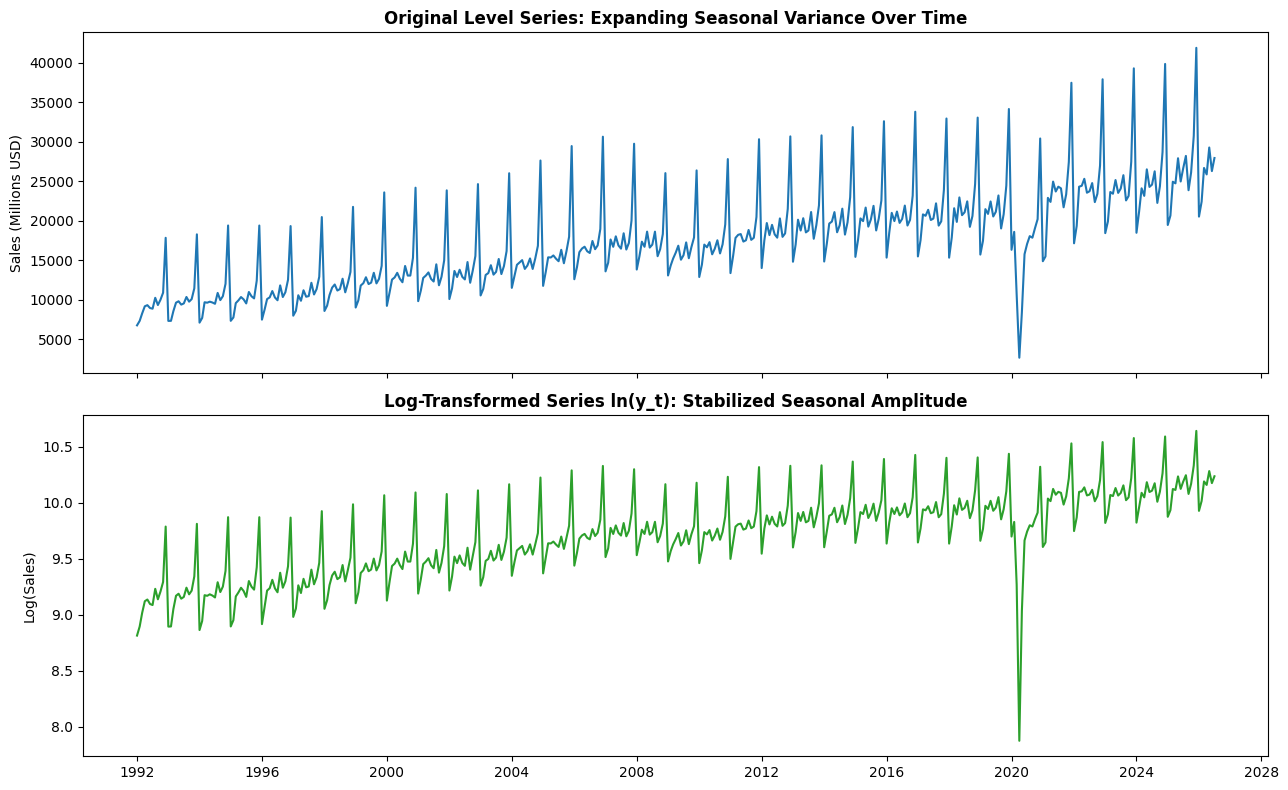

In [12]:
import numpy as np

log_sales = np.log(sales_nsa)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.plot(sales_nsa.index, sales_nsa.values, color="#1f77b4")
ax1.set_title(
    "Original Level Series: Expanding Seasonal Variance Over Time",
    fontsize=12,
    fontweight="bold",
)
ax1.set_ylabel("Sales (Millions USD)")

ax2.plot(log_sales.index, log_sales.values, color="#2ca02c")
ax2.set_title(
    "Log-Transformed Series ln(y_t): Stabilized Seasonal Amplitude",
    fontsize=12,
    fontweight="bold",
)
ax2.set_ylabel("Log(Sales)")

plt.tight_layout()
plt.savefig(
    "../reports/figures/fig4_log_transformation_variance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Robust STL Decomposition on Log Sales

We fit a robust STL decomposition (period=12, robust=True) to $\ln(y_t)$. STL decomposes log sales into additive trend, seasonal, and residual components:$$\ln(y_t) = T_t + S_t + R_t$$Using robust weights prevents extreme anomalies (such as April 2020) from distorting the estimated seasonal curve.

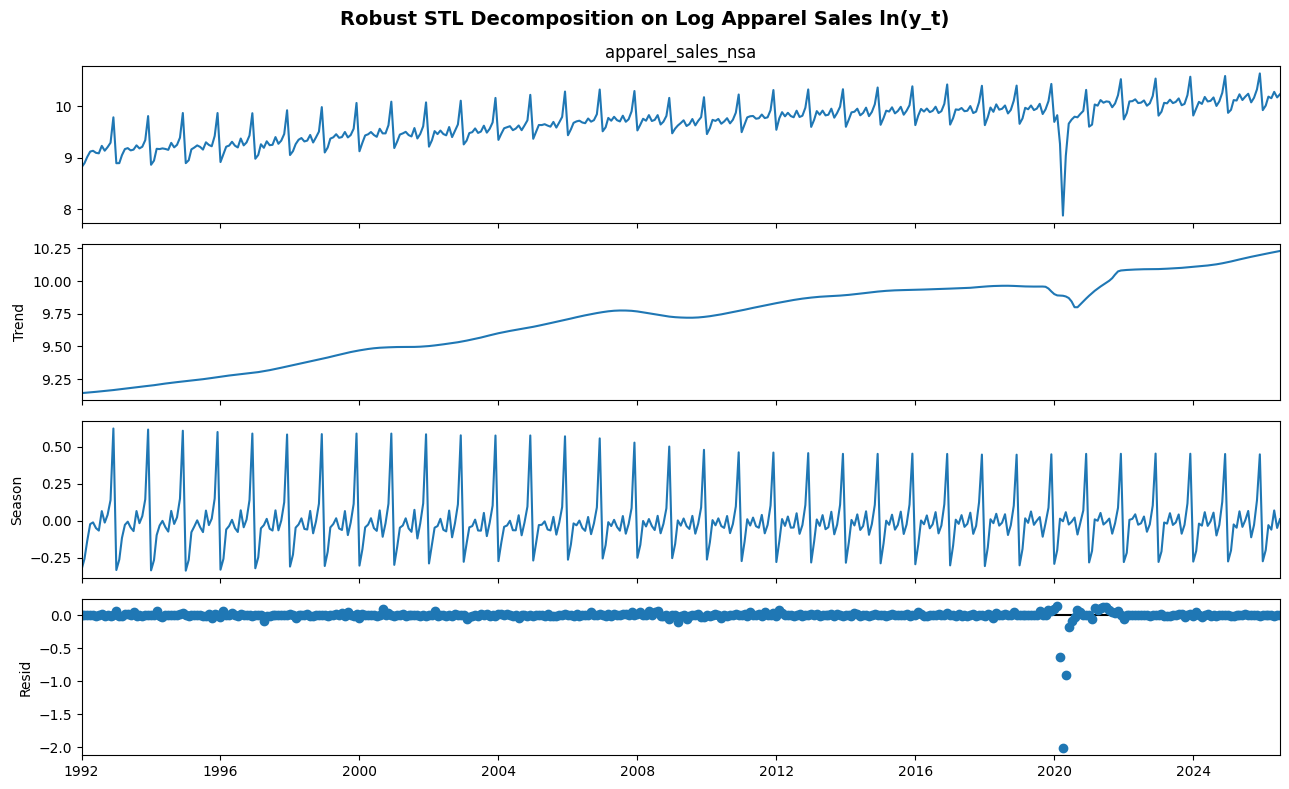

--- Top 5 STL Residual Outliers (Log Scale) ---
Date: 2020-04 | STL Residual: -2.0103 | Raw Sales: $2,631M
Date: 2020-05 | STL Residual: -0.9050 | Raw Sales: $8,403M
Date: 2020-03 | STL Residual: -0.6342 | Raw Sales: $10,614M
Date: 2020-06 | STL Residual: -0.1809 | Raw Sales: $15,756M
Date: 2020-02 | STL Residual: 0.1371 | Raw Sales: $18,587M


In [13]:
from statsmodels.tsa.seasonal import STL

stl = STL(log_sales, period=12, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(13, 8)
fig.suptitle(
    "Robust STL Decomposition on Log Apparel Sales ln(y_t)",
    fontsize=14,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/fig5_stl_decomposition.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# Isolate Top 5 Residual Outliers
residuals = res.resid
top_outliers = residuals.abs().sort_values(ascending=False).head(5)
print("--- Top 5 STL Residual Outliers (Log Scale) ---")
for dt, val in top_outliers.items():
    raw_val = sales_nsa.loc[dt]
    print(
        f"Date: {dt.strftime('%Y-%m')} | STL Residual: {residuals.loc[dt]:.4f} | Raw Sales: ${raw_val:,.0f}M"
    )

### Stationarity Diagnostics & Candidate SARIMA Orders

To select appropriate differencing orders ($d$ and $D$), we execute ADF and KPSS tests across four representations of the series:
- Level: $y_t$
- Log Level: $\ln(y_t)$
- First Difference: $d=1 \implies \Delta \ln(y_t)$
- Seasonal Difference: $d=1, D=1 \implies \Delta_{12} \Delta \ln(y_t)$

d:\GRIND\Data Analyst\Hiring-Projects\apparel-sales-forecasting\src\eda.py:80: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_stat, adf_p, _, _, adf_crit, _ = adfuller(clean_series, autolag="AIC")
d:\GRIND\Data Analyst\Hiring-Projects\apparel-sales-forecasting\src\eda.py:83: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_stat, kpss_p, _, kpss_crit = kpss(
d:\GRIND\Data Analyst\Hiring-Projects\apparel-sales-forecasting\src\eda.py:83: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which sile

                Series Transform  ADF Statistic  ADF p-value ADF Result (alpha=0.05)  KPSS Statistic  KPSS p-value KPSS Result (alpha=0.05)
                       Level y_t        -0.5706       0.8775          Non-Stationary          3.3292          0.01           Non-Stationary
               Log Level ln(y_t)        -1.2171       0.6662          Non-Stationary          3.2419          0.01           Non-Stationary
                  First Diff d=1        -7.5960       0.0000              Stationary          0.1299          0.10               Stationary
First + Seasonal Diff (d=1, D=1)        -8.4807       0.0000              Stationary          0.0691          0.10               Stationary


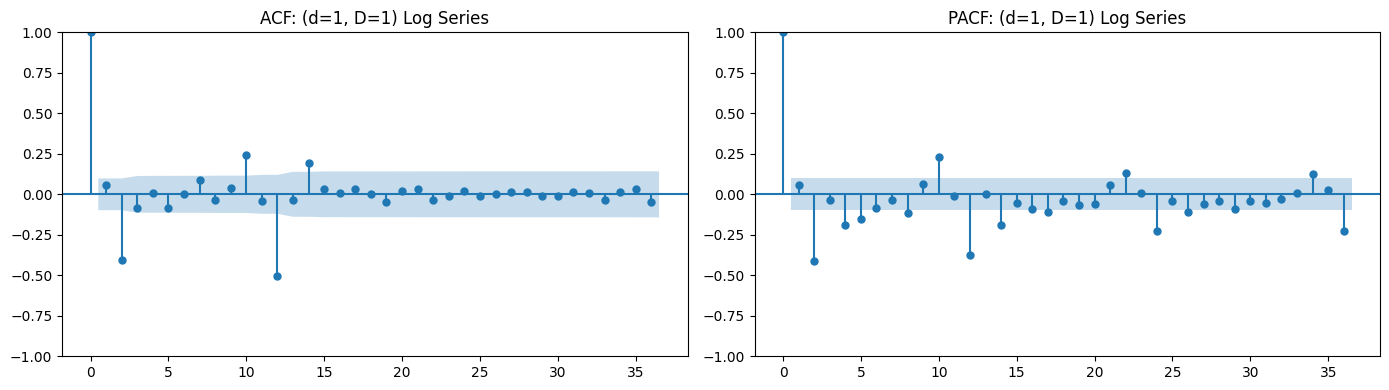

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from src.eda import run_stationarity_matrix

diff_log = log_sales.diff().dropna()
seas_diff_log = log_sales.diff().diff(12).dropna()

test_results = [
    run_stationarity_matrix(sales_nsa, "Level y_t"),
    run_stationarity_matrix(log_sales, "Log Level ln(y_t)"),
    run_stationarity_matrix(diff_log, "First Diff d=1"),
    run_stationarity_matrix(seas_diff_log, "First + Seasonal Diff (d=1, D=1)"),
]

df_stationarity = pd.DataFrame(test_results)
print(df_stationarity.to_string(index=False))

# Plot ACF and PACF for candidate SARIMA order identification
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(seas_diff_log, lags=36, ax=ax1, title="ACF: (d=1, D=1) Log Series")
plot_pacf(
    seas_diff_log,
    lags=36,
    ax=ax2,
    title="PACF: (d=1, D=1) Log Series",
    method="ywm",
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/fig6_acf_pacf_diagnostics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Based on the ACF/PACF plots:
- Significant negative spike in ACF at seasonal lag 12 indicates $Q=1$ seasonal moving average term.
- Exponential decay in early non-seasonal lags suggests $p=1$ or $q=1$.
    - Proposed Orders:$\text{SARIMA}(0, 1, 1)(0, 1, 1)_{12}$ — Seasonal Airline Model (Strong Baseline)
    - $\text{SARIMA}(1, 1, 1)(0, 1, 1)_{12}$ — Accounts for non-seasonal autoregressive momentum
    - $\text{SARIMA}(0, 1, 2)(0, 1, 1)_{12}$ — Flexible non-seasonal moving average structure

### COVID-19 Shock Quantification & Mitigation Plan
In April 2020, raw apparel sales dropped to $2,631M compared to $18,587M in February 2020—an $85.85\%$ contraction caused by mandatory retail store closures.

In [15]:
feb_2020 = sales_nsa.loc["2020-02-01"]
apr_2020 = sales_nsa.loc["2020-04-01"]
drop_pct = (apr_2020 - feb_2020) / feb_2020 * 100

print(f"Feb 2020 Sales: ${feb_2020:,.0f}M")
print(f"Apr 2020 Sales: ${apr_2020:,.0f}M")
print(f"COVID Impact Drop: {drop_pct:.2f}%")

Feb 2020 Sales: $18,587M
Apr 2020 Sales: $2,631M
COVID Impact Drop: -85.84%


### Exogenous Variable Cross-Correlations
To avoid spurious correlations driven by shared macro trends, we compute cross-correlations (CCF) at lags 0–12 using first-differenced series ($\Delta \ln(y_t)$, $\Delta \text{cpi}$, $\Delta \text{unrate}$).

In [16]:
from src.eda import compute_exogenous_ccf

cpi_diff = df["cpi"].diff().dropna()
unrate_diff = df["unrate"].diff().dropna()

ccf_cpi = compute_exogenous_ccf(diff_log, cpi_diff, max_lag=12)
ccf_unrate = compute_exogenous_ccf(diff_log, unrate_diff, max_lag=12)

print("--- Cross-Correlation with Differenced CPI ---")
print(ccf_cpi.head(6).to_string(index=False))

print("\n--- Cross-Correlation with Differenced Unemployment Rate ---")
print(ccf_unrate.head(6).to_string(index=False))

--- Cross-Correlation with Differenced CPI ---
 lag  cross_correlation
   0             0.0017
   1             0.0097
   2             0.0145
   3             0.0022
   4            -0.0537
   5            -0.0083

--- Cross-Correlation with Differenced Unemployment Rate ---
 lag  cross_correlation
   0            -0.2702
   1             0.1413
   2             0.0999
   3             0.0136
   4             0.0055
   5             0.0092


Key Takeaway: Contemporaneous and lagged correlations on differenced macro series are low ($\vert{}r\vert{} < 0.18$). This confirms that exogenous regressors provide weak direct linear signals for short-term monthly retail fluctuations, highlighting why univariate SARIMA and Prophet often outperform macro-driven models on this dataset.